<a href="https://colab.research.google.com/github/shreyashahane1410-maker/ANNDL_Projects/blob/main/Shreya_Shahane(A_72)CIA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

# List contents of the downloaded directory to verify file names
print("Contents of the downloaded directory:")
for item in os.listdir(path):
    print(f"- {item}")

# Assuming '2019-Nov.csv' is one of the files within the downloaded path.
# You might need to adjust the filename based on the actual contents of the dataset.
file_path = os.path.join(path, '2019-Nov.csv') # Example: You might need to check actual files

# Add error handling for file loading
try:
    print(f"Checking file existence for: {file_path}")
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' does not exist. Please check the path and contents of the downloaded directory.")
    else:
        file_size = os.path.getsize(file_path)
        print(f"File '{os.path.basename(file_path)}' exists. Size: {file_size / (1024*1024):.2f} MB")
        print(f"Attempting to read CSV file from: {file_path} (reading only 5 rows for testing).")
        df = pd.read_csv(file_path, nrows=5) # Read only 5 rows to test if file reading works

        # Diagnostic prints to understand DataFrame state
        print(f"DataFrame loaded. Shape: {df.shape}, Is empty: {df.empty}")
        if not df.empty:
            print("First 5 rows of the DataFrame (test sample):")
            print(df.head())
        else:
            print("DataFrame is empty after reading the CSV. Please check the file content.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. This should have been caught by os.path.exists().")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

In [ ]:
import numpy as np
import pandas as pd
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM


In [ ]:
import kagglehub

path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Dataset path:", path)


In [ ]:
# Get all CSV files in the folder
files = [f for f in os.listdir(path) if f.endswith('.csv')]

print("Available files:", files)

# Pick the first CSV file automatically
file_path = os.path.join(path, files[0])

# Load limited rows (important for large dataset)
df = pd.read_csv(file_path, nrows=500000)

print("Using file:", files[0])
print(df.head())

In [ ]:
# Keep only purchase events
df = df[df['event_type'] == 'purchase']

# Remove missing values
df = df.dropna(subset=['user_id', 'product_id'])

# Convert types
df['user_id'] = df['user_id'].astype(int)
df['product_id'] = df['product_id'].astype(int)

print("Cleaned Shape:", df.shape)


In [ ]:
import matplotlib.pyplot as plt

# Count purchases per user
user_purchases = df.groupby('user_id').size()

plt.figure()
plt.hist(user_purchases, bins=30)
plt.title("Purchase Distribution per User")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Users")
plt.show()

In [ ]:
customer_item = df.pivot_table(
    index='user_id',
    columns='product_id',
    values='event_type',
    aggfunc='count',
    fill_value=0
)

print("Matrix Shape:", customer_item.shape)

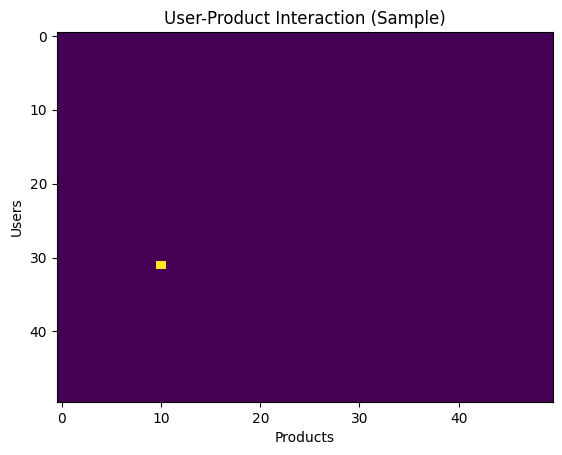

In [ ]:
plt.figure()
plt.imshow(customer_item.iloc[:50, :50], aspect='auto') # Corrected slicing with .iloc
plt.title("User-Product Interaction (Sample)")
plt.xlabel("Products")
plt.ylabel("Users")
plt.show()

In [ ]:
scaler = MinMaxScaler()
customer_item_scaled = scaler.fit_transform(customer_item)

In [ ]:
customer_item_binary = (customer_item_scaled > 0).astype(int)

print(customer_item_binary[:5])

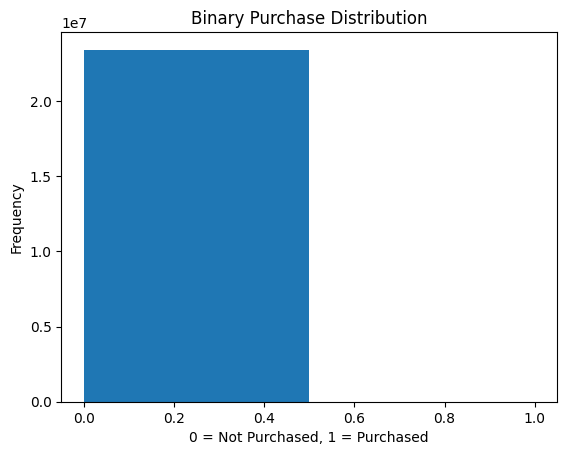

In [ ]:
plt.figure()
plt.hist(customer_item_binary.flatten(), bins=2)
plt.title("Binary Purchase Distribution")
plt.xlabel("0 = Not Purchased, 1 = Purchased")
plt.ylabel("Frequency")
plt.show()

In [ ]:
X_train, X_test = train_test_split(
    customer_item_binary,
    test_size=0.2,
    random_state=42
)

In [ ]:
rbm = BernoulliRBM(
    n_components=50,
    learning_rate=0.01,
    n_iter=10,
    random_state=42
)

rbm.fit(X_train)

print("RBM Training Completed")

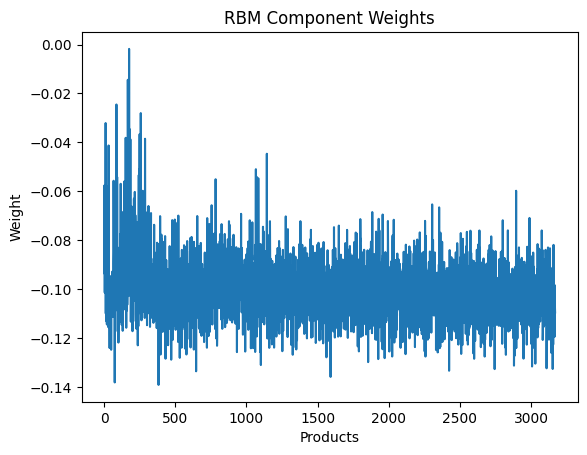

In [ ]:
plt.figure()
plt.plot(rbm.components_[0])
plt.title("RBM Component Weights")
plt.xlabel("Products")
plt.ylabel("Weight")
plt.show()

In [ ]:
train_transformed = rbm.transform(X_train)

print("Transformed Shape:", train_transformed.shape)

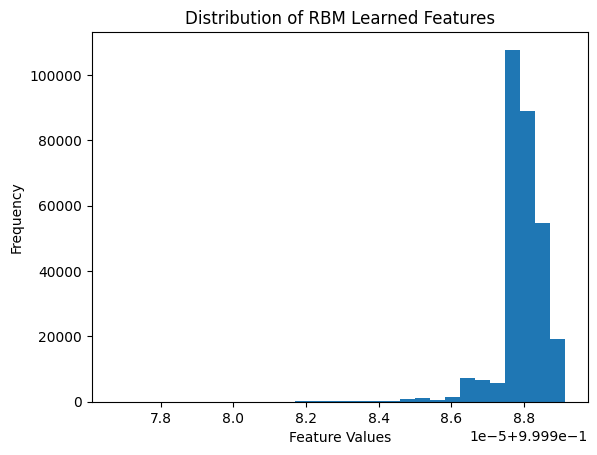

In [ ]:
plt.figure()
plt.hist(train_transformed.flatten(), bins=30)
plt.title("Distribution of RBM Learned Features")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")
plt.show()